In [16]:
!pip install librosa tensorflow numpy scikit-learn matplotlib requests

In [17]:
import librosa
import librosa.display
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os, requests, zipfile, io

In [20]:
print("Downloading dataset...")
url = "https://github.com/Jakobovski/free-spoken-digit-dataset/archive/master.zip"
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    zip_ref.extractall("fsdd")

In [21]:
data_path = "fsdd/free-spoken-digit-dataset-master/recordings"
print("Dataset downloaded and extracted successfully!")

Dataset downloaded and extracted successfully!


In [23]:
def extract_features(file_path):
  y, sr = librosa.load(file_path, sr=None)
  mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
  return np.mean(mfccs.T, axis=0)


In [24]:
print("Extracting features from audio files...")
X = []
y = []

Extracting features from audio files...


In [26]:
for file in os.listdir(data_path):
  if file.endswith(".wav"):
    label = file.split("_")[0] # 0–9
    feature = extract_features(os.path.join(data_path, file))
    X.append(feature)
    y.append(label)


/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1149
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1542
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1565
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1843
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1742
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1774
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py

In [27]:
X = np.array(X)
y = np.array(y)
print("Feature extraction complete! Shape:", X.shape)

Feature extraction complete! Shape: (3000, 40)


In [28]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y_encoded, test_size=0.2, random_state=42
)
print(" Data split: Train =", len(X_train), ", Test =", len(X_test))


 Data split: Train = 2400 , Test = 600


In [30]:
model = tf.keras.models.Sequential([
tf.keras.layers.Dense(256, activation='relu', input_shape=(40,)),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(128, activation='relu'),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,682 (174.54 KB)

 Trainable params: 44,682 (174.54 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
print("Training the model...")
history = model.fit(X_train, y_train, epochs=40, batch_size=16, validation_data=(X_test, y_test))


Training the model...
Epoch 1/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1533 - loss: 6.5791 - val_accuracy: 0.1717 - val_loss: 2.2250
Epoch 2/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2042 - loss: 2.2115 - val_accuracy: 0.2617 - val_loss: 1.9770
Epoch 3/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2412 - loss: 1.9946 - val_accuracy: 0.3200 - val_loss: 1.7228
Epoch 4/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2858 - loss: 1.8633 - val_accuracy: 0.4000 - val_loss: 1.5427
Epoch 5/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3388 - loss: 1.6949 - val_accuracy: 0.4867 - val_loss: 1.3448
Epoch 6/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3979 - loss: 1.5638 - val_accuracy: 0.6167 - val_loss: 1.1173
Epoch 7/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4621 - loss: 1.3775 - val_accuracy: 0.6433 - val_loss: 1.0004
Epoch 8/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5146 - loss: 1.2

In [33]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f" Test Accuracy: {test_acc * 100:.2f}%")


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9683 - loss: 0.1056
 Test Accuracy: 96.83%


Text(0.5, 1.0, 'Model Accuracy')

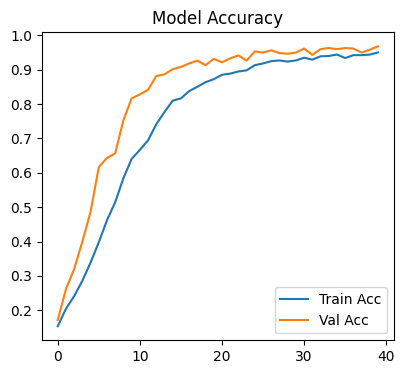

In [34]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Model Accuracy')

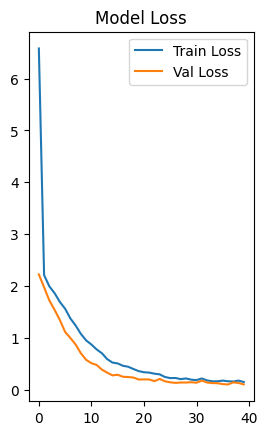

In [35]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [37]:
def predict_audio(file_path):
  feature = extract_features(file_path)
  feature = np.expand_dims(feature, axis=0)
  pred = model.predict(feature)
  predicted_label = le.inverse_transform([np.argmax(pred)])
  print("🎤 Predicted Digit:", predicted_label[0])


In [38]:
sample_file = os.path.join(data_path, "3_jackson_0.wav")
predict_audio(sample_file)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
🎤 Predicted Digit: 3
